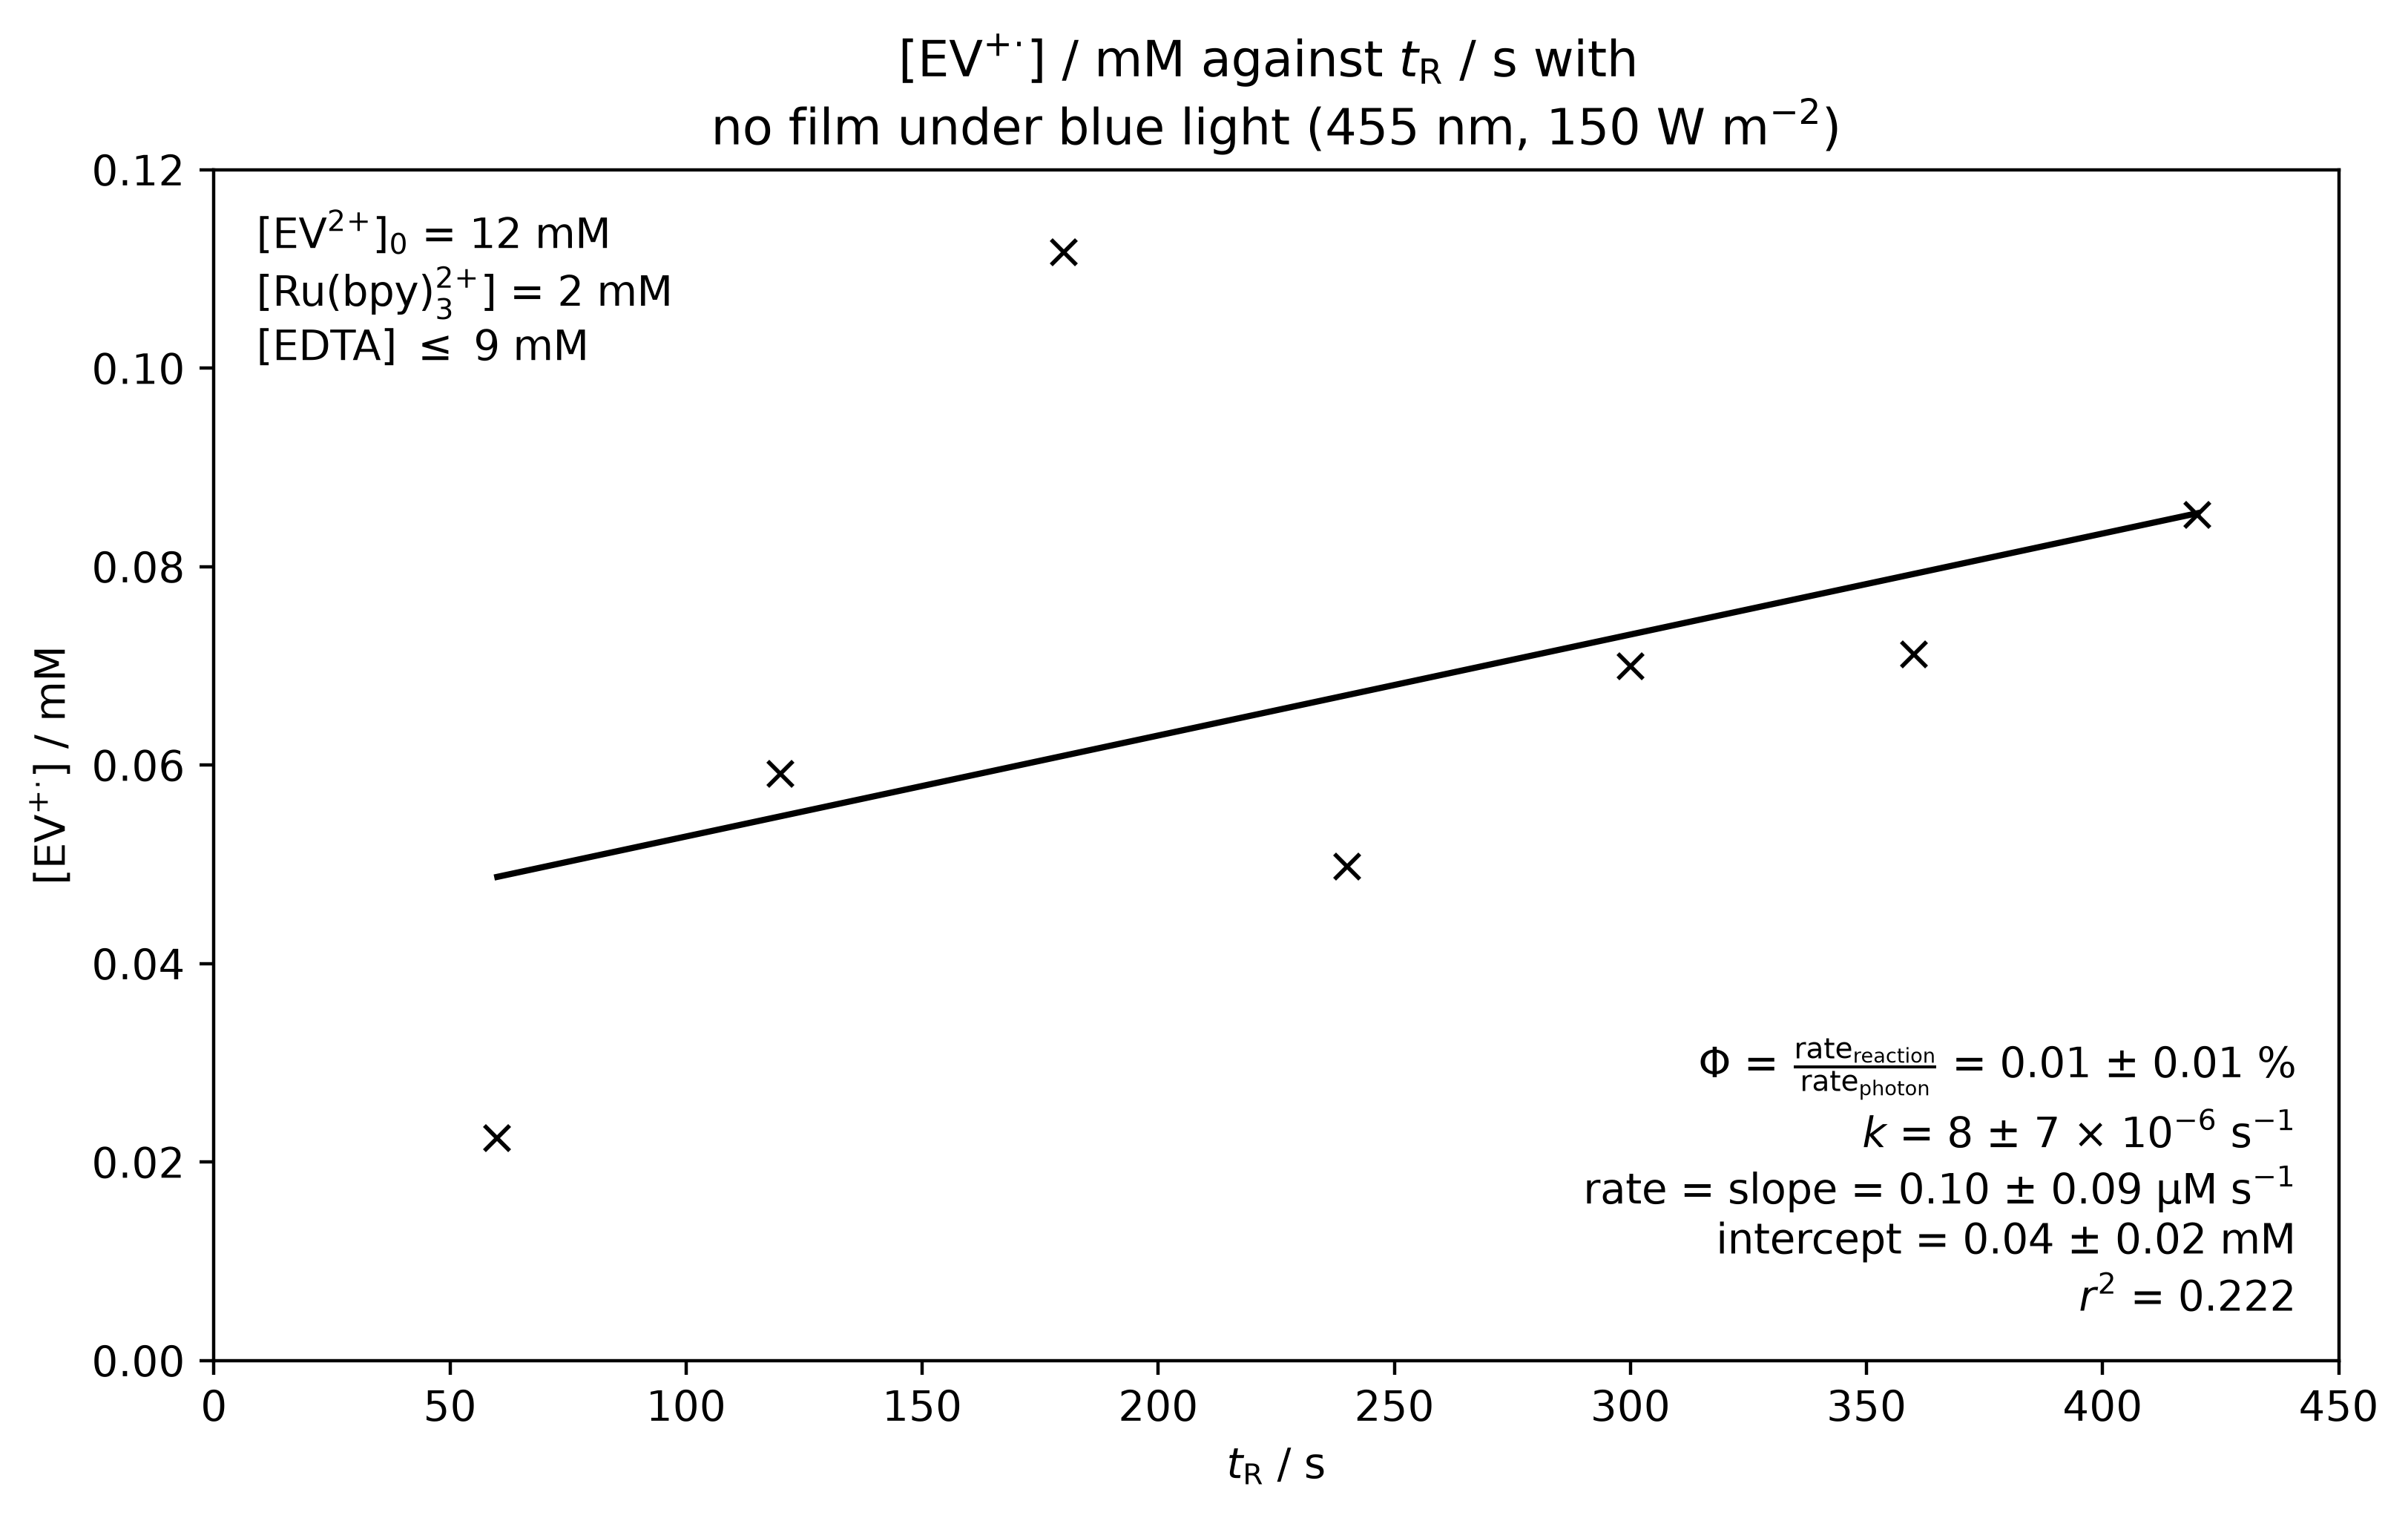

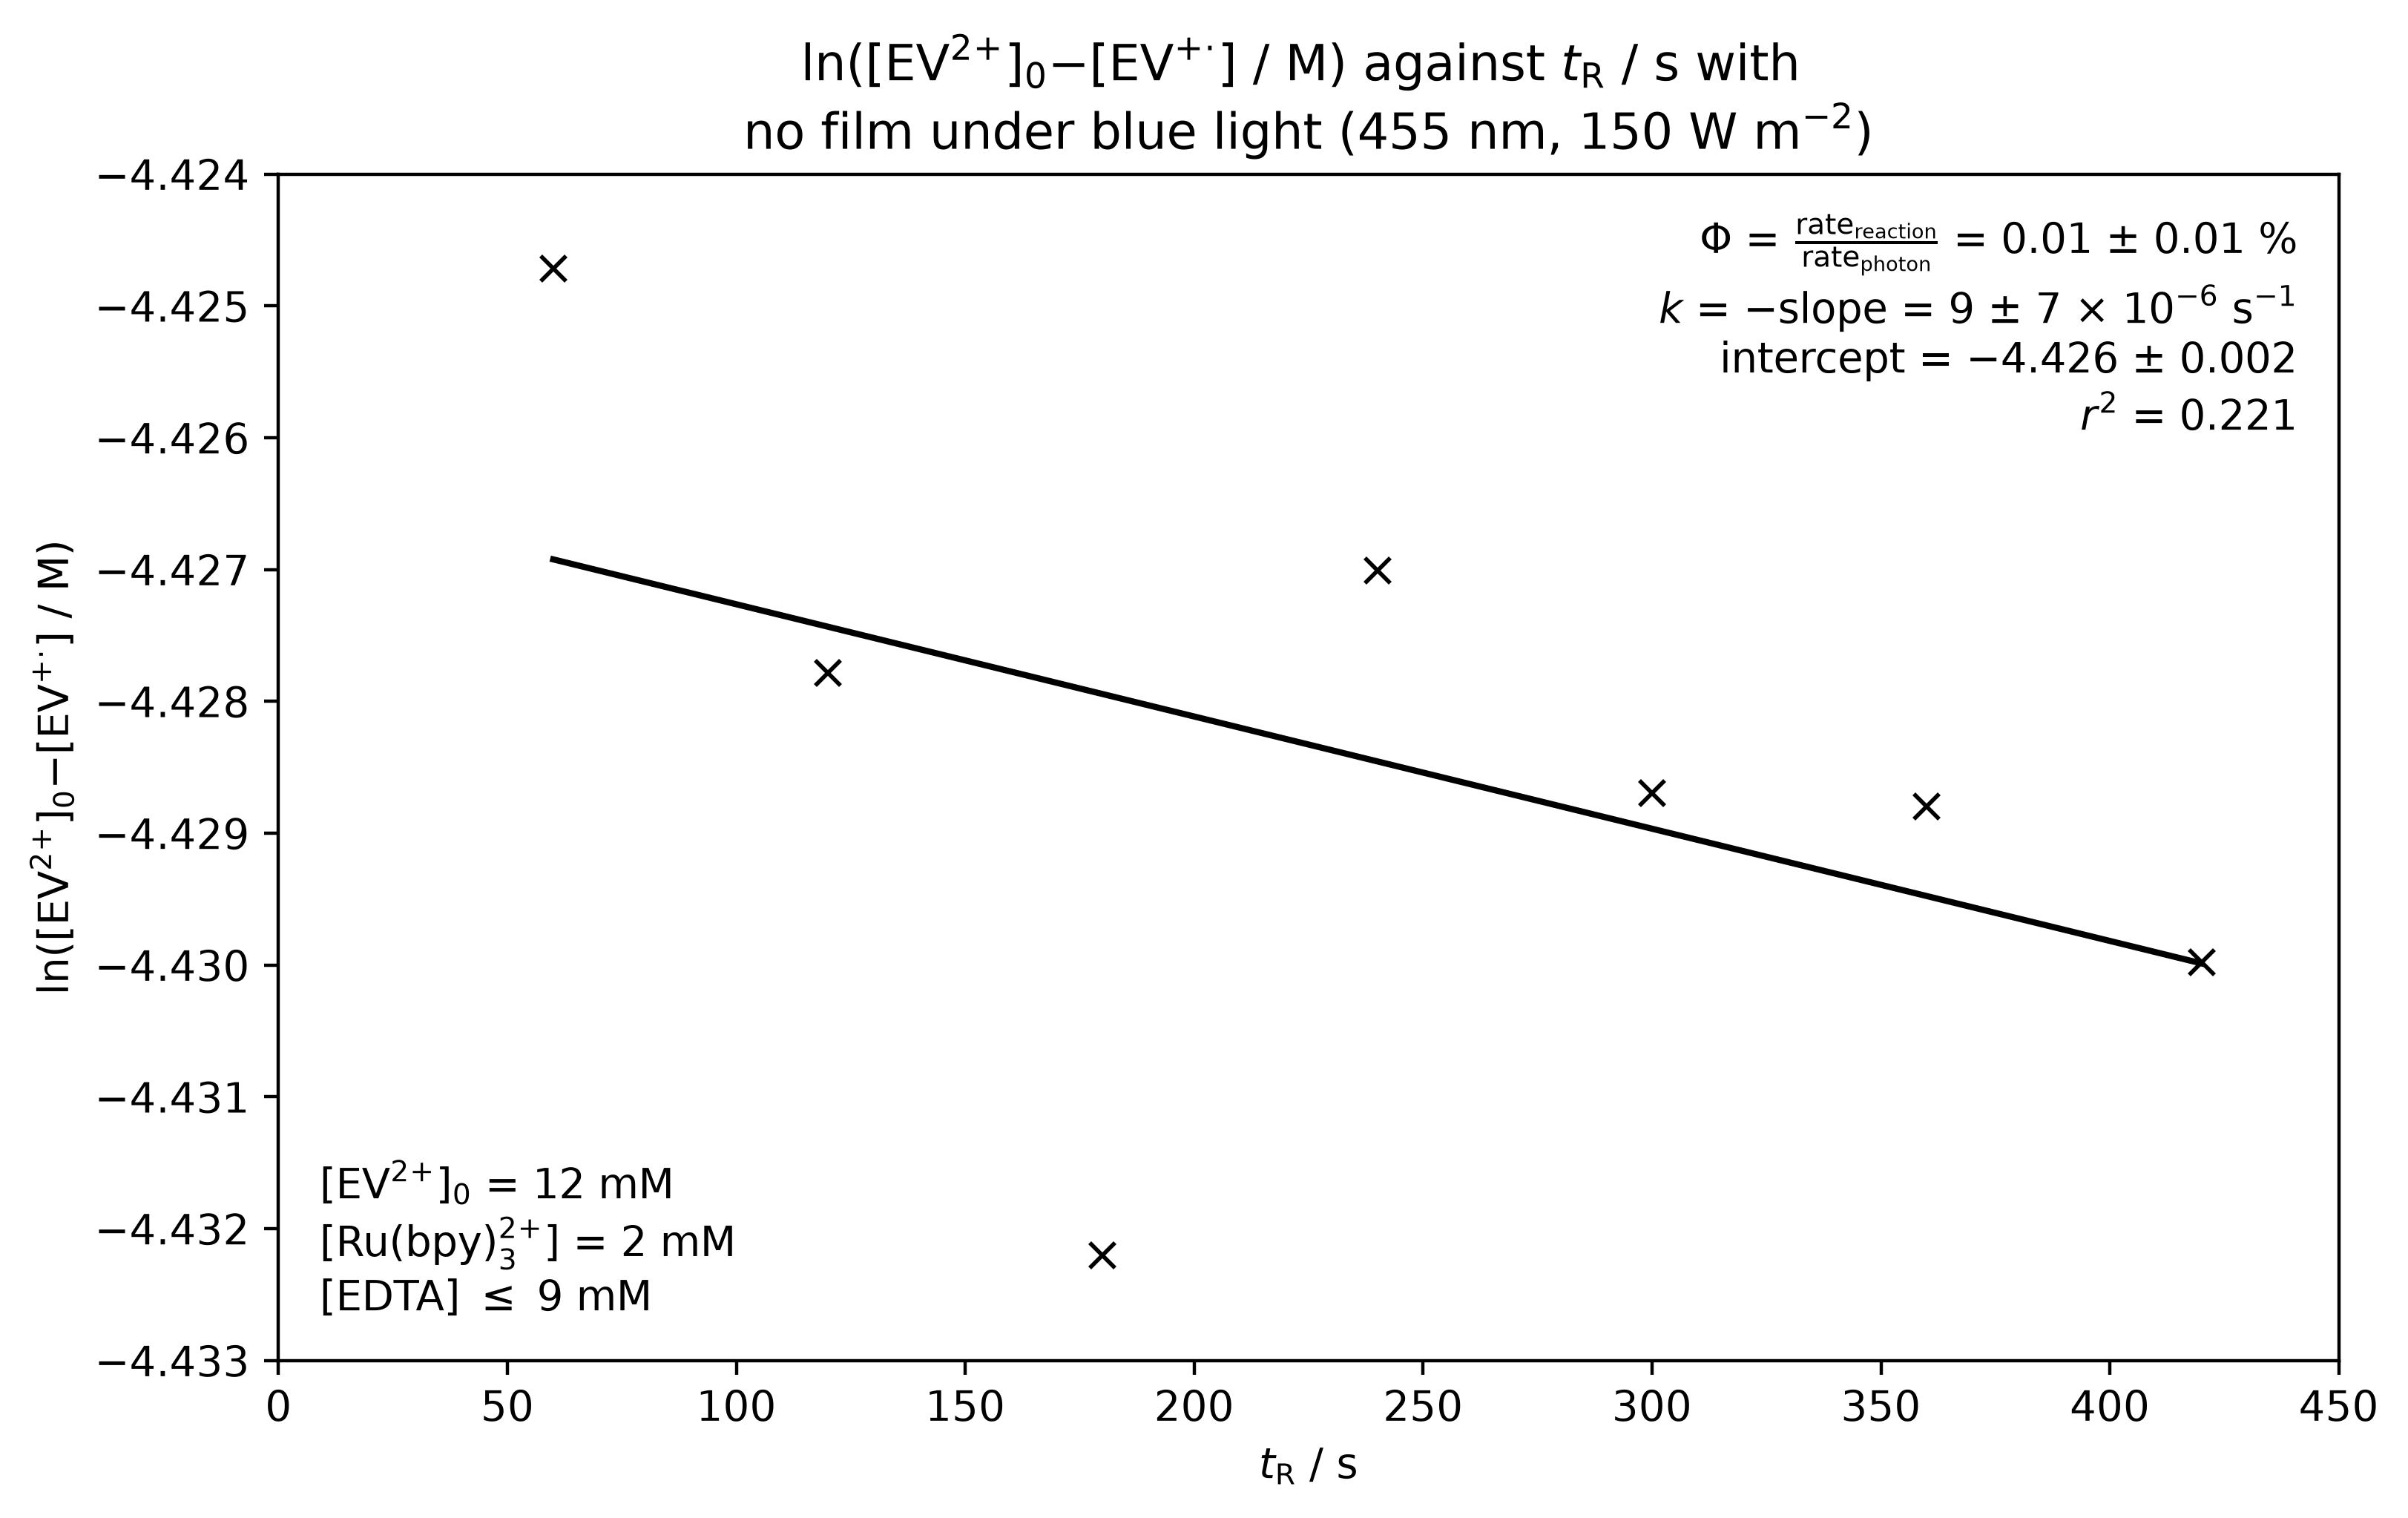

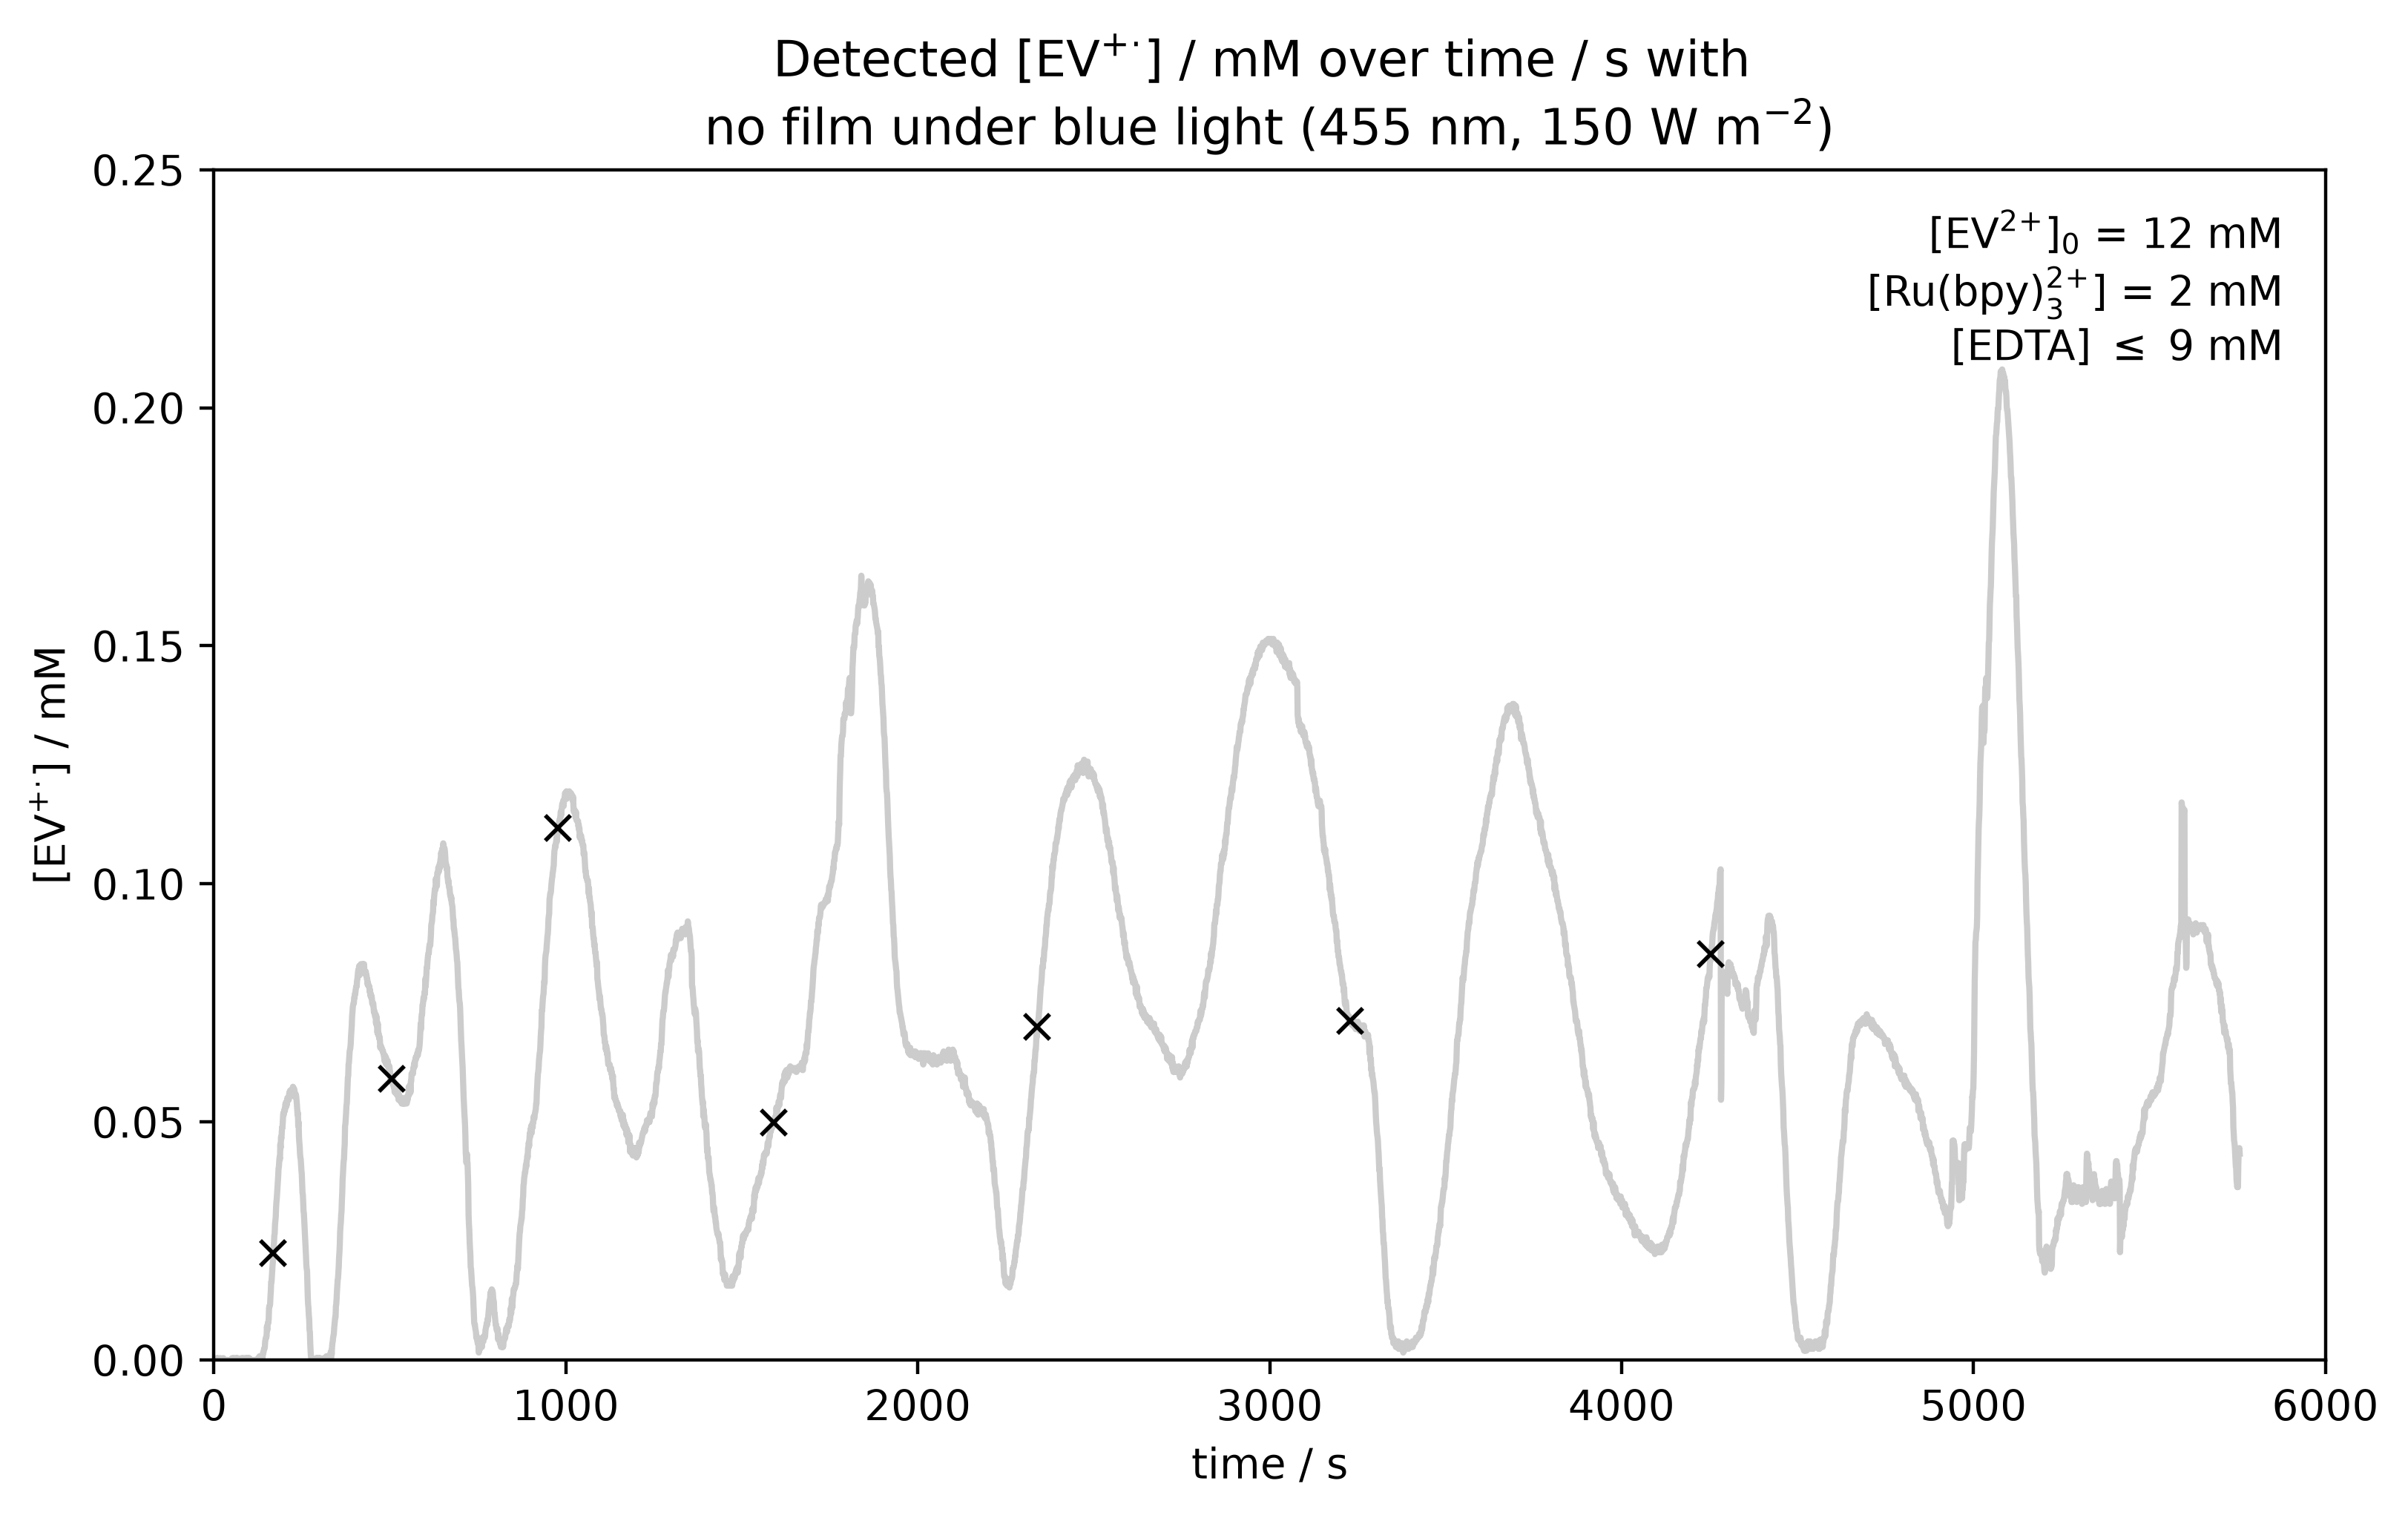

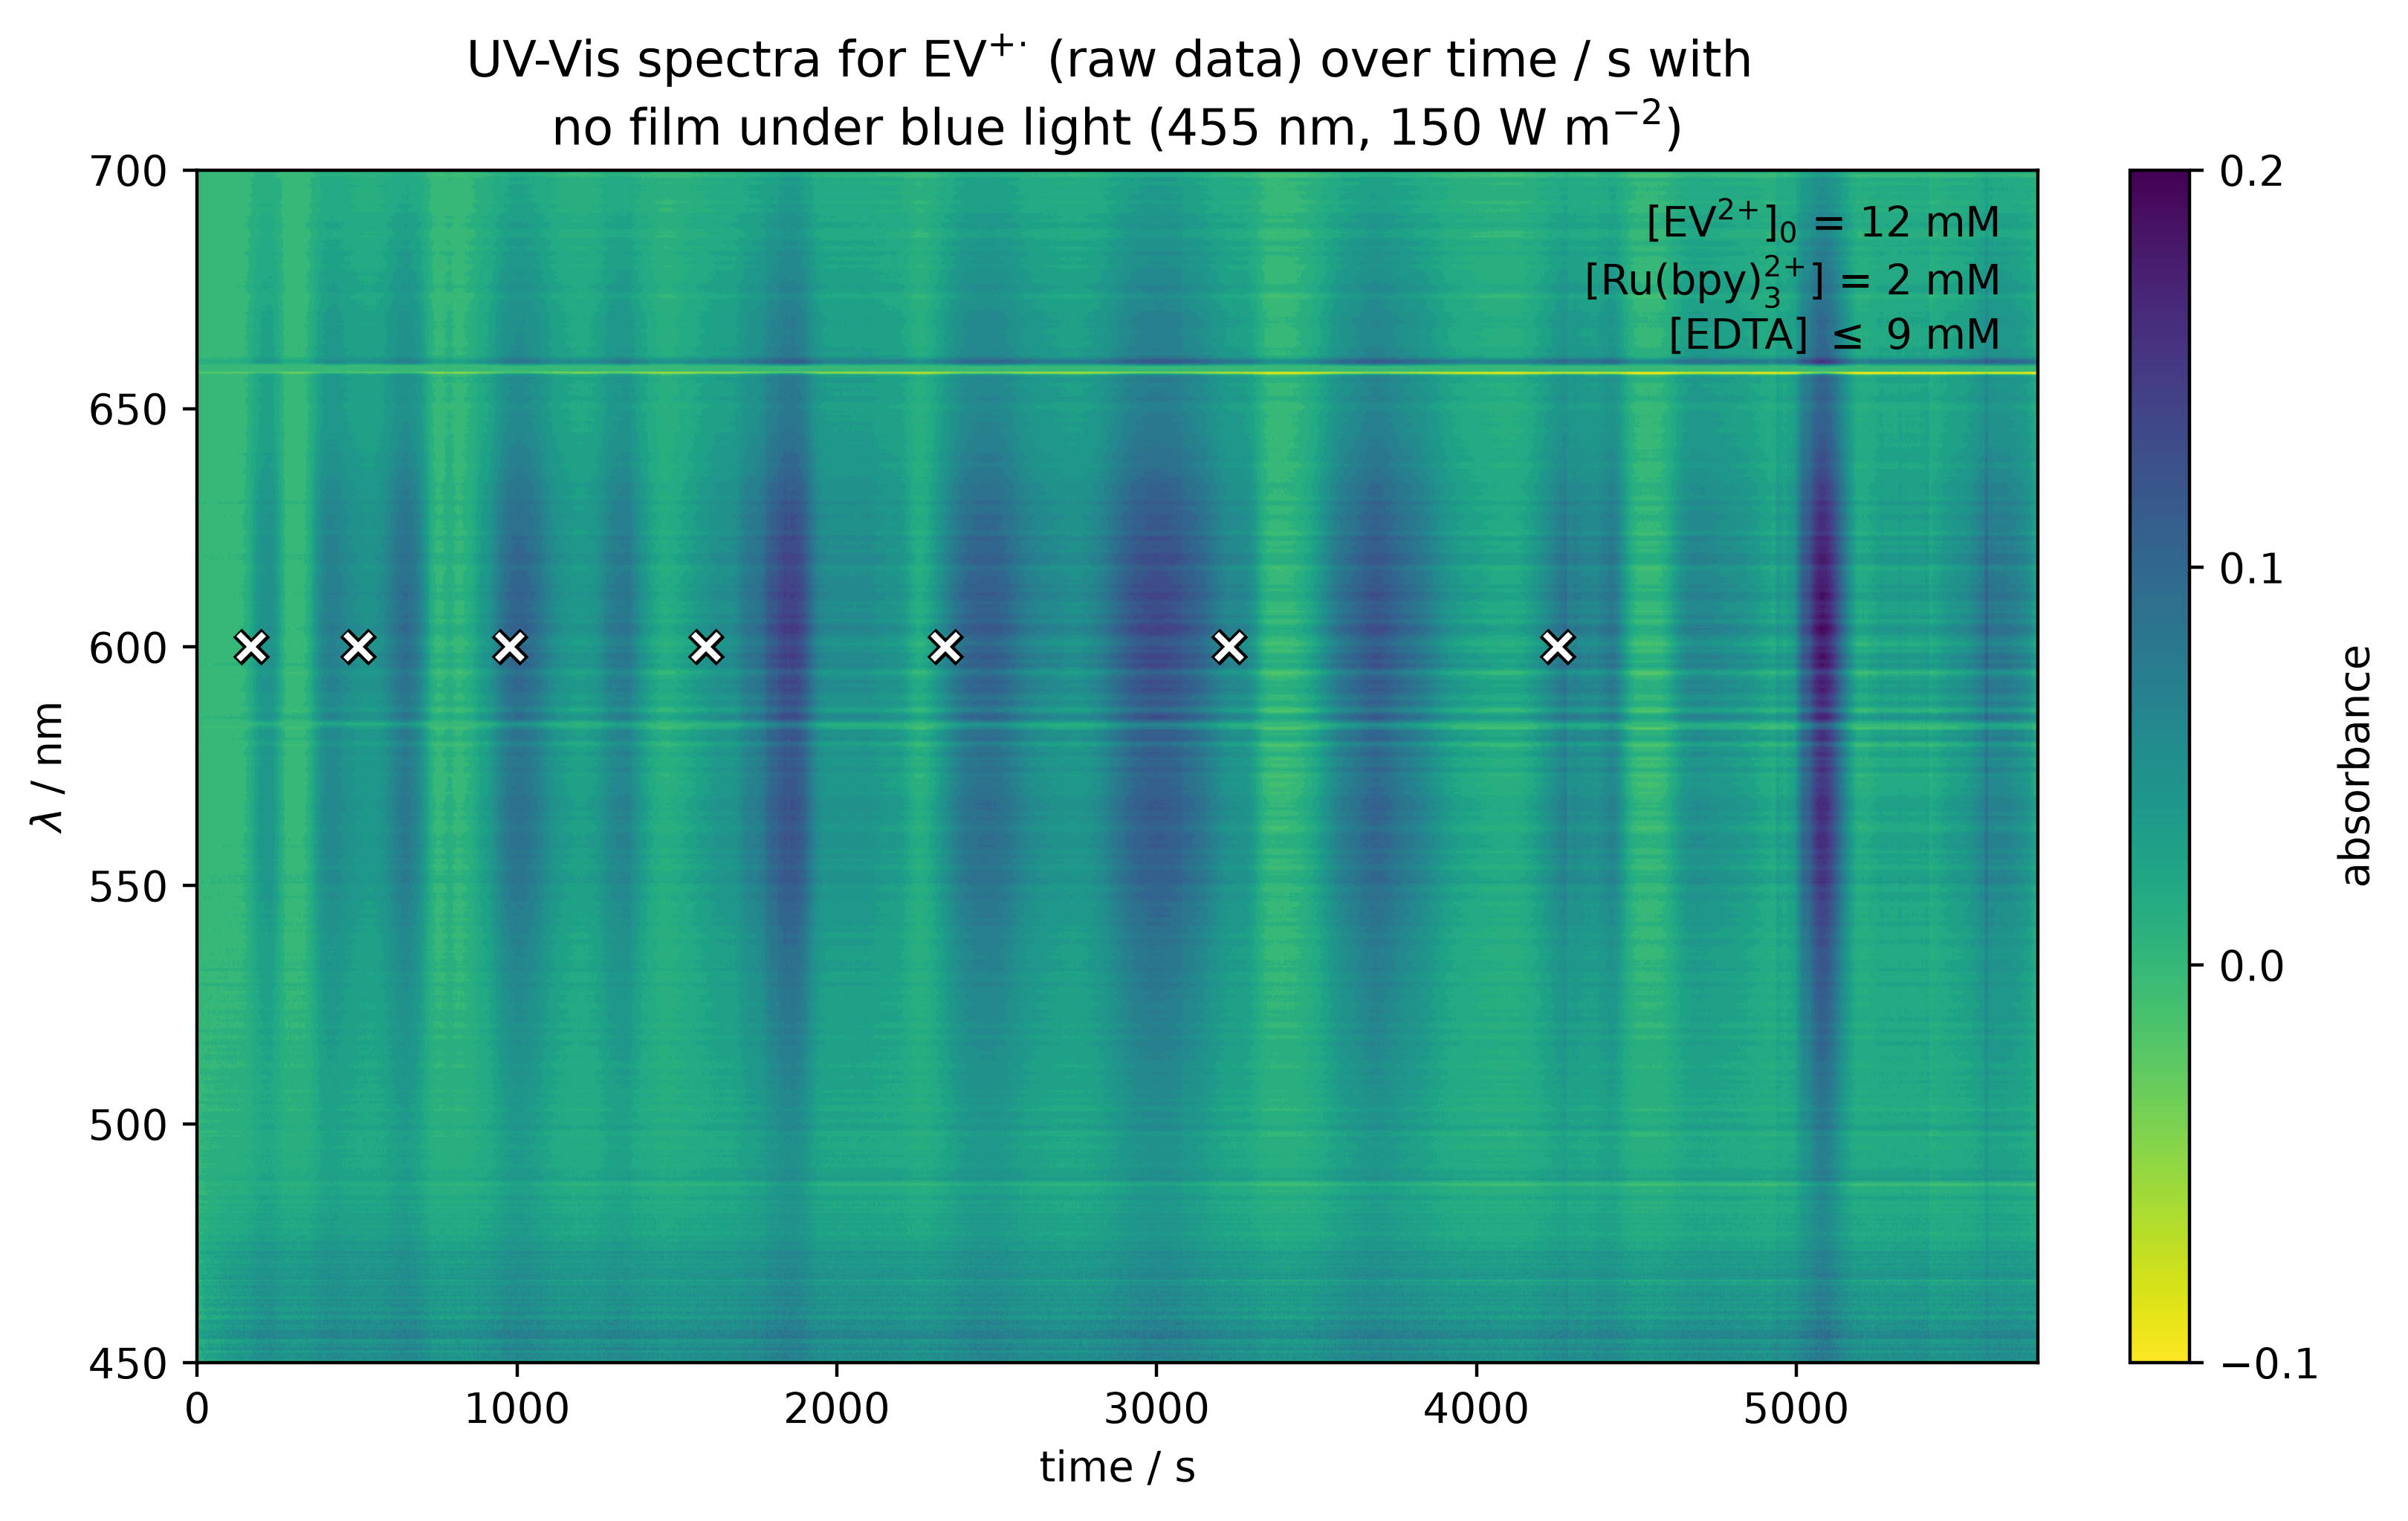

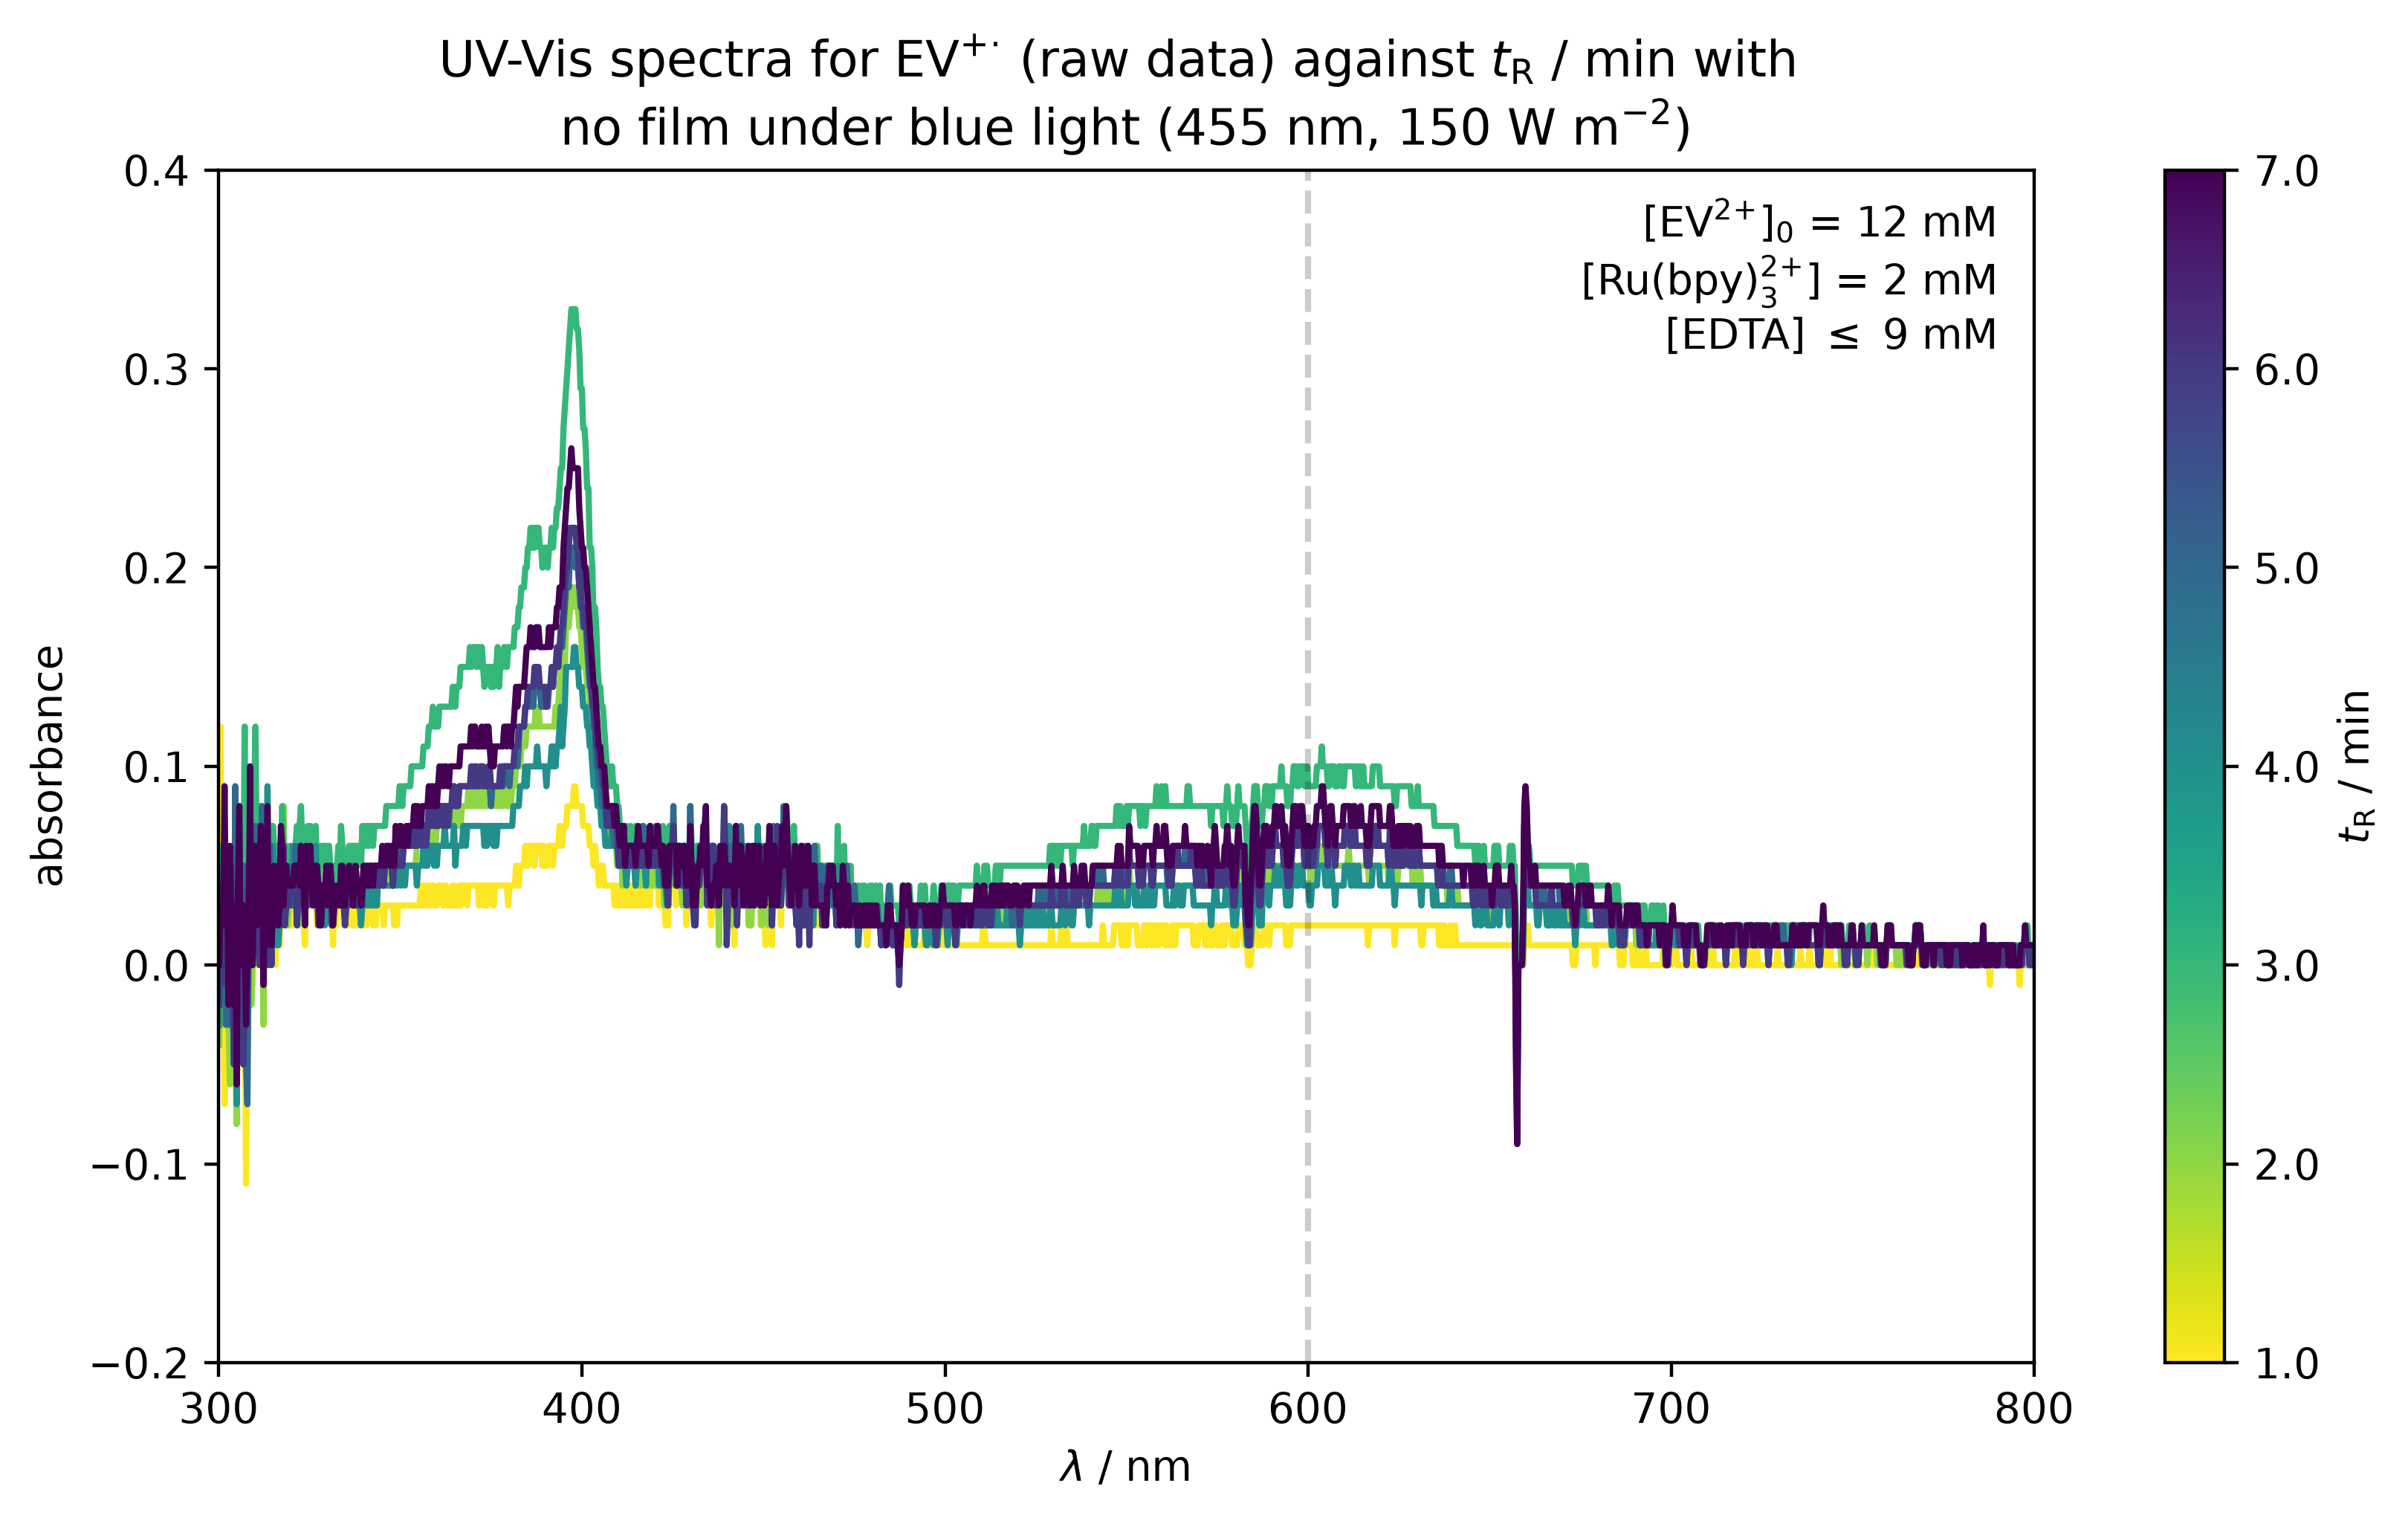

In [1]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS, X
import numpy as np

"""
Continuous flow with reaction/LED/film in one 50 ul reactor chamber and UV-Vis on a different 50 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Mixing due to turbulent flow in the connecting tubing results in EV+. decay, poor coorelation between tR and recorded absorbance.

V([Ru(bpy)3]2+, 12.5 mM, pH 6 buffer) = 240 ul (2 mM),
V(EV2+, 25 mM, pH 6 buffer) = 720 ul (12 mM),
V(EDTA, <25 mM saturated, pH 6 buffer) = 540 ul (<9 mM).
"""

data = '260703_Rubpy_EV_EDTA_Flow' # data folder name

tRs = np.arange(60, 7*60+1, 60) # residence times in s for 1-7 min in 1 min intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['2x50ul']) # time points in s to record absorbances
start = "14-01-00-000" # recorded start time

c0 = 12e-3 # initial EV2+ concentration
details = f'{X['RU']} = 2 mM\n[EDTA] $\\leq$ 9 mM' # concentrations of other reagents

x = 'EVrubpy2x50ul'
film = 'no'
light = 'blue'
wavelength = 455e-9 # m
power = 10.6e-3 # W

expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power, correction=False)
expt.concvstimeplot()
expt.concvstimeplot(ln=True)
expt.detectorconcplot()
expt.detectorspectrumplot()
expt.spectrumvstimeplot()